# Obtaining data for MA-DPG evaluation form example 02b


In [1]:
# Module imports
import os
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils as utils
from sqlalchemy import create_engine

# assume module imports
import examples as examples
from assume import World
from assume.scenario.loader_csv import load_file, load_scenario_folder

c:\Users\tg3533\AppData\Local\miniconda3\envs\assume-framework\Lib\site-packages\pyomo\common\dependencies.py:471: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  self._loader.exec_module(module)


## 1. Setting scenario parameters

In [2]:
if current_dir := os.path.basename(os.getcwd()) == "MPEC":
    %cd ../../..

example = "small_learning_with_storage"
# actual equilibrium prices
# because one can just see it actually

# all learning units only needed when the demand exceeds 7000 MW and hence only then market power is necessary
equi = [
    36.156,
    36.156,
    36.156,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    85.708,
    85.708,
    85.708,
    85.708,
    85.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
    55.708,
]
# equi = [36.156, 36.156, 36.156] + [55.708] * 20
db_uri = "sqlite:///./examples/local_db/assume_db_8459abd.db"
inputs_dir = "examples/inputs"

scenario = "example_02e"
study_case = "base"

# Set up the database connection
db = create_engine(db_uri)

c:\Users\tg3533\Documents\Code\assume


In [3]:
os.getcwd()

'c:\\Users\\tg3533\\Documents\\Code\\assume'

## 2. Retrieving the data from the best run

### 2.2 Getting the demand dataframe and power plant units

In [4]:
study_case_config = utils.load_config(inputs_dir, scenario, study_case)
start = pd.Timestamp(study_case_config["start_date"])
end = pd.Timestamp(study_case_config["end_date"])

index = pd.date_range(
    start=start,
    end=end,
    freq=study_case_config["time_step"],
)

demand_df = load_file(
    os.path.join(inputs_dir, scenario), study_case_config, "demand_df", index
)
demand_df.head()

INFO:assume.scenario.loader_csv:Downsampling demand_df successful.


,demand_EOM
2019-03-01 00:00:00,5078.7
2019-03-01 01:00:00,4920.7
2019-03-01 02:00:00,4832.5
2019-03-01 03:00:00,4849.5
2019-03-01 04:00:00,5014.2


In [5]:
pp_units = pd.read_csv(
    os.path.join(inputs_dir, scenario, "powerplant_units.csv"), index_col=0
)
pp_units.reset_index(inplace=True)
pp_units.rename(columns={"name": "unit"}, inplace=True)
pp_units

,unit,technology,bidding_EOM,fuel_type,emission_factor,max_power,min_power,efficiency,additional_cost,unit_operator
0,pp_1,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,10.0,Operator 1
1,pp_2,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,12.0,Operator 1
2,pp_3,lignite,powerplant_energy_naive,lignite,0.406,1000,1,0.41,2.0,Operator 1
3,pp_4,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,1.0,Operator 1
4,pp_5,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,4.0,Operator 1
5,pp_6,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,4.0,Operator 1
6,pp_7,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,10.0,Operator 1
7,pp_8,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,16.0,Operator 1
8,pp_9,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,24.0,Operator 1
9,pp_10,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,30.0,Operator 1


In [6]:
# read storages similar to pp_units
storage_units = pd.read_csv(
    os.path.join(inputs_dir, scenario, "storage_units.csv"), index_col=0
)
storage_units

,technology,bidding_EOM,max_power_charge,max_power_discharge,efficiency_charge,efficiency_discharge,min_soc,max_soc,capacity,initial_soc,additional_cost_charge,additional_cost_discharge,natural_inflow,unit_operator
name,,,,,,,,,,,,,,
Storage 1,PSPP,storage_energy_learning,500,500,0.85,0.95,0.0,1.0,5000,0.0,0.28,0.28,0.0,Operator 1


## NOTE: Delete base dispatch if you retrained

In [7]:
config = utils.load_config(inputs_dir, scenario)
if f"{study_case}_dispatch" in config:
    del config[f"{study_case}_dispatch"]
# Copy the base and new base_dispatch configuration
base_config = config[study_case].copy()
base_dispatch = config[study_case].copy()
base_dispatch["learning_config"] = base_config["learning_config"].copy()

# Modify learning config parameters for base_dispatch
base_dispatch["learning_config"].update(
    {
        "continue_learning": False,
        "trained_policies_save_path": "learned_strategies/base_dispatch/last_policies",
        "trained_policies_load_path": "learned_strategies/base_dispatch/avg_reward_eval_policies",
        "training_episodes": 0,
        "episodes_collecting_initial_experience": 0,
    }
)

base_dispatch.update(
    {
        "learning_mode": False,
    }
)

# Update the config with both sections
config[study_case] = base_config
config[f"{study_case}_dispatch"] = base_dispatch

# Write the updated config back to file
utils.store_config(config, inputs_dir, scenario)

# Define paths
base_dir = Path(
    os.path.join(inputs_dir, scenario, f"learned_strategies/{scenario}_{study_case}")
)
dispatch_dir = Path(
    os.path.join(inputs_dir, scenario, f"learned_strategies/{study_case}_dispatch")
)

# Check if source directory exists
if not base_dir.exists():
    print(f"Source directory {base_dir} does not exist!")
elif dispatch_dir.exists():
    print(f"Target directory {dispatch_dir} already exists!")
else:
    # Create target directory if it doesn't exist
    dispatch_dir.parent.mkdir(parents=True, exist_ok=True)

    # Copy directory
    shutil.copytree(base_dir, dispatch_dir)
    print(f"Successfully copied {base_dir} to {dispatch_dir}")

Target directory examples\inputs\example_02e\learned_strategies\base_dispatch already exists!


In [8]:
world = World(database_uri=db_uri)

load_scenario_folder(world, inputs_dir, scenario, f"{study_case}_dispatch")

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: examples/inputs/example_02e
INFO:assume.scenario.loader_csv:Study case: base_dispatch
INFO:assume.scenario.loader_csv:Simulation ID: example_02e_base_dispatch
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:exchange_units not found. Returning None
INFO:assume.scenario.loader_csv:industrial_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:Downsampling demand_df successful.
INFO:assume.scenario.loader_csv:exchanges_df not found. Returning None
INFO:assume.scenario.loader_csv:availability_df not found. Returning None
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv

### Get mc

Since we want to avoid logging the mc in assume itself, because this is slowing the simualtion down I will get them afterwards. Curretnly the script only runs with time-invariant mc. Hence I test here if that si still the case. 

In [9]:
units = world.unit_operators["Operator 1"].units
for name, unit in units.items():
    if (
        hasattr(unit, "marginal_cost")
        and unit.marginal_cost is not None
        and np.all(np.array(unit.marginal_cost) != 0)
    ):
        mc = np.array(unit.marginal_cost)
        # Check all values are the same
        assert np.all(mc == mc[0]), f"Marginal costs for {name} are not constant: {mc}"
        # Check none are zero
        assert np.all(mc != 0), f"Marginal costs for {name} contain zero: {mc}"
        print(f"{name}: marginal_cost = {mc[0]}")
    else:
        # For storages or units without marginal_cost, use average of additional_cost_charge and additional_cost_discharge
        charge = getattr(unit, "additional_cost_charge", None)
        discharge = getattr(unit, "additional_cost_discharge", None)
        if charge is not None and discharge is not None:
            avg_cost = (charge + discharge) / 2
            print(f"{name}: average storage cost = {avg_cost}")
        else:
            print(f"{name}: No marginal or storage cost found!")

pp_1: marginal_cost = 12.5
pp_2: marginal_cost = 14.5
pp_3: marginal_cost = 31.146341463414636
pp_4: marginal_cost = 36.15625
pp_5: marginal_cost = 39.15625
pp_6: marginal_cost = 55.708333333333336
pp_7: marginal_cost = 61.708333333333336
pp_8: marginal_cost = 67.70833333333334
pp_9: marginal_cost = 75.70833333333334
pp_10: marginal_cost = 81.70833333333334
pp_11: marginal_cost = 87.70833333333334
pp_12: marginal_cost = 91.70833333333334


In [10]:
# Suppose unit.marginal_cost is a list/array of values for each unit
# Collect all marginal_cost series in a dict
costs_dict = {
    name: (
        unit.marginal_cost
        if hasattr(unit, "marginal_cost")
        and unit.marginal_cost is not None
        and np.all(np.array(unit.marginal_cost) != 0)
        else (
            (
                getattr(unit, "additional_cost_charge", None)
                + getattr(unit, "additional_cost_discharge", None)
            )
            / 2
            if getattr(unit, "additional_cost_charge", None) is not None
            and getattr(unit, "additional_cost_discharge", None) is not None
            else None
        )
    )
    for name, unit in world.unit_operators["Operator 1"].units.items()
}

# Find the length of the series (assuming all are the same length)
n = len(next(iter(costs_dict.values())))

# Optionally, create a time index (e.g., hourly from start_date)
start = pd.Timestamp(study_case_config["start_date"])
time_index = pd.date_range(start=start, periods=n, freq="h")  # adjust freq as needed

# Create the DataFrame
marginal_costs_df = pd.DataFrame(costs_dict, index=time_index)
marginal_costs_df

,pp_1,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9,pp_10,pp_11,pp_12
2019-03-01 00:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-03-01 01:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-03-01 02:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-03-01 03:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-03-01 04:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-04-29 20:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-04-29 21:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-04-29 22:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333
2019-04-29 23:00:00,12.5,14.5,31.146341,36.15625,39.15625,55.708333,61.708333,67.708333,75.708333,81.708333,87.708333,91.708333


In [11]:
query = f"SELECT * FROM market_orders where simulation = '{scenario}_{study_case}'"
market_orders_df = pd.read_sql(query, db)
market_orders_df

,start_time,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume
0,2019-03-01 01:00:00.000000,39.15625,1000.0,pp_1_1,None,2019-03-01 02:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.0
1,2019-03-01 01:00:00.000000,39.15625,1000.0,pp_2_1,None,2019-03-01 02:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.0
2,2019-03-01 01:00:00.000000,39.15625,1000.0,pp_3_1,None,2019-03-01 02:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.0
3,2019-03-01 01:00:00.000000,39.15625,1000.0,pp_4_1,None,2019-03-01 02:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.0
4,2019-03-01 01:00:00.000000,39.15625,920.7,pp_5_1,None,2019-03-01 02:00:00.000000,EOM,node0,39.156250,example_02e_base,pp_5,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20141,2019-04-29 23:00:00.000000,39.15625,0.0,pp_9_1,None,2019-04-30 00:00:00.000000,EOM,node0,75.708333,example_02e_base,pp_9,500.0
20142,2019-04-29 23:00:00.000000,39.15625,0.0,pp_10_1,None,2019-04-30 00:00:00.000000,EOM,node0,81.708333,example_02e_base,pp_10,500.0
20143,2019-04-29 23:00:00.000000,39.15625,0.0,pp_11_1,None,2019-04-30 00:00:00.000000,EOM,node0,87.708333,example_02e_base,pp_11,500.0
20144,2019-04-29 23:00:00.000000,39.15625,0.0,pp_12_1,None,2019-04-30 00:00:00.000000,EOM,node0,91.708333,example_02e_base,pp_12,500.0


# 3. Establish Sampling of days to be analysed

Here we sample from the entire training data a subset of days, for which we test if the profit of all drl agents is similar to their MPEC formulation. 

In [12]:
sampled_indices = utils.sample_seasonal_weeks(demand_df.index)
# TODO: LÖSCHEN NUR FÜR FASTER SOLAVBIILTY AS 1 Week runs into run time limit
sampled_indices = sampled_indices[:1]

sampled_indices = [demand_df.index.date[0]]
sampled_indices

Spring complete weeks: [np.uint32(10), np.uint32(11), np.uint32(12), np.uint32(13), np.uint32(14), np.uint32(15), np.uint32(16), np.uint32(17)]
Summer complete weeks: []
Fall complete weeks: []
Winter complete weeks: []


[datetime.date(2019, 3, 1)]

## 3.1 Get sample subset

In [13]:
demand_df["date"] = demand_df.index.date
sample_demand_df = demand_df.loc[demand_df["date"].isin(sampled_indices)]
rest_demand_df = demand_df.loc[~demand_df["date"].isin(sampled_indices)]
sample_demand_df.head()

,demand_EOM,date
2019-03-01 00:00:00,5078.7,2019-03-01
2019-03-01 01:00:00,4920.7,2019-03-01
2019-03-01 02:00:00,4832.5,2019-03-01
2019-03-01 03:00:00,4849.5,2019-03-01
2019-03-01 04:00:00,5014.2,2019-03-01


In [14]:
query = f"SELECT * FROM unit_dispatch where simulation = '{scenario}_{study_case}'"
dispatch_df = pd.read_sql(query, db)
# dispatch_df = dispatch_df.drop_duplicates(subset=["time", "unit"], keep="first")

dispatch_df = dispatch_df.sort_values("time")


dispatch_df.index = pd.to_datetime(dispatch_df["time"])
dispatch_df.drop(columns=["time"], inplace=True)
dispatch_df["date"] = dispatch_df.index.date

# merge marginal_costs based on unit and time
# Reset index to get time as a column
mc_long = marginal_costs_df.reset_index().melt(
    id_vars="index", var_name="unit", value_name="marginal_cost"
)
mc_long = mc_long.rename(columns={"index": "time"})  # Rename index to time if needed

# Now merge with dispatch_df on 'time' and 'unit'
dispatch_df = dispatch_df.merge(mc_long, on=["time", "unit"], how="left")

sample_dispatch_df = dispatch_df.loc[dispatch_df["date"].isin(sampled_indices)]
rest_dispatch_df = dispatch_df.loc[~dispatch_df["date"].isin(sampled_indices)]
sample_dispatch_df

,time,energy_cashflow,energy_generation_costs,heat,power,simulation,soc,total_costs,unit,date,marginal_cost
0,2019-03-01 00:00:00,NaN,0.000000,0.0,0.0,example_02e_base,NaN,NaN,pp_1,2019-03-01,12.500000
1,2019-03-01 00:00:00,NaN,0.000000,NaN,0.0,example_02e_base,NaN,NaN,demand_EOM,2019-03-01,NaN
2,2019-03-01 00:00:00,NaN,0.000000,NaN,0.0,example_02e_base,0.0,NaN,Storage 1,2019-03-01,NaN
3,2019-03-01 00:00:00,NaN,0.000000,0.0,0.0,example_02e_base,NaN,NaN,pp_12,2019-03-01,91.708333
4,2019-03-01 00:00:00,NaN,0.000000,0.0,0.0,example_02e_base,NaN,NaN,pp_11,2019-03-01,87.708333
...,...,...,...,...,...,...,...,...,...,...,...
331,2019-03-01 23:00:00,55708.333333,36156.250000,0.0,1000.0,example_02e_base,NaN,NaN,pp_4,2019-03-01,36.156250
332,2019-03-01 23:00:00,55708.333333,31146.341463,0.0,1000.0,example_02e_base,NaN,NaN,pp_3,2019-03-01,31.146341
333,2019-03-01 23:00:00,55708.333333,14500.000000,0.0,1000.0,example_02e_base,NaN,NaN,pp_2,2019-03-01,14.500000
334,2019-03-01 23:00:00,55708.333333,12500.000000,0.0,1000.0,example_02e_base,NaN,NaN,pp_1,2019-03-01,12.500000


In [15]:
# sample market orders as well
market_orders_df.index = pd.to_datetime(market_orders_df["start_time"])
market_orders_df = market_orders_df.drop(columns=["start_time"])
market_orders_df["date"] = market_orders_df.index.date

sample_market_orders_df = market_orders_df.loc[
    market_orders_df["date"].isin(sampled_indices)
]
rest_market_orders_df = market_orders_df.loc[
    ~market_orders_df["date"].isin(sampled_indices)
]
sample_market_orders_df.head()

,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume,date
start_time,,,,,,,,,,,,
2019-03-01 01:00:00,39.15625,1000.0,pp_1_1,None,2019-03-01 02:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.0,2019-03-01
2019-03-01 01:00:00,39.15625,1000.0,pp_2_1,None,2019-03-01 02:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.0,2019-03-01
2019-03-01 01:00:00,39.15625,1000.0,pp_3_1,None,2019-03-01 02:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.0,2019-03-01
2019-03-01 01:00:00,39.15625,1000.0,pp_4_1,None,2019-03-01 02:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.0,2019-03-01
2019-03-01 01:00:00,39.15625,920.7,pp_5_1,None,2019-03-01 02:00:00.000000,EOM,node0,39.156250,example_02e_base,pp_5,1000.0,2019-03-01


## 3.2 Analyse sample distribution in comparison to entire dataset

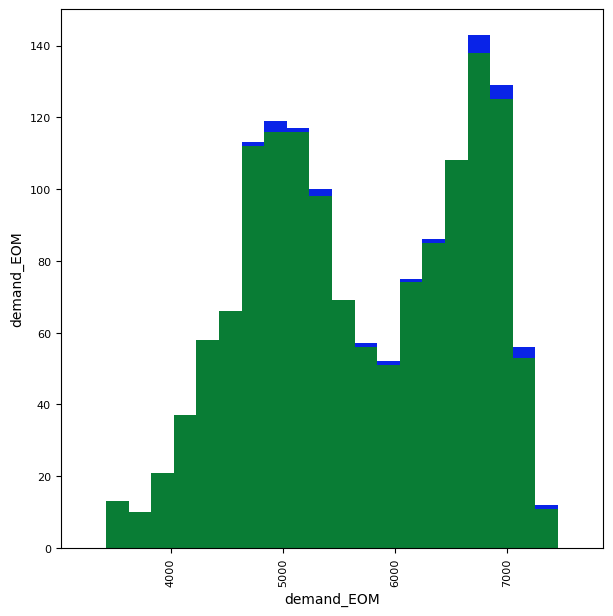

In [16]:
utils.plot_sample_distribution(sample_demand_df, rest_demand_df)

## 2.3 Bi-Level Optimisation 

### Defintion for case

In [17]:
big_w = 100000  # weight for duality gap objective
k_max = 2  # maximum multiplier for strategic bidding

### Input data transformation for Optimisation Problem 

In [18]:
# gens
gens_df = utils.create_gens_df(pp_units, dispatch_df)
gens_df.head(15)

,index,unit,technology,bidding_EOM,fuel_type,emission_factor,g_max,u_0,efficiency,additional_cost,unit_operator,r_up,r_down,k_up,k_down,g_0,mc
0,0,pp_1,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,10.0,Operator 1,1000,1000,0,0,0,12.500000
1,1,pp_2,nuclear,powerplant_energy_naive,uranium,0.000,1000,1,0.36,12.0,Operator 1,1000,1000,0,0,0,14.500000
2,2,pp_3,lignite,powerplant_energy_naive,lignite,0.406,1000,1,0.41,2.0,Operator 1,1000,1000,0,0,0,31.146341
3,3,pp_4,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,1.0,Operator 1,1000,1000,0,0,0,36.156250
4,4,pp_5,hard coal,powerplant_energy_naive,hard coal,0.335,1000,1,0.48,4.0,Operator 1,1000,1000,0,0,0,39.156250
5,5,pp_6,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,4.0,Operator 1,500,500,0,0,0,55.708333
6,6,pp_7,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,10.0,Operator 1,500,500,0,0,0,61.708333
7,7,pp_8,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,16.0,Operator 1,500,500,0,0,0,67.708333
8,8,pp_9,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,24.0,Operator 1,500,500,0,0,0,75.708333
9,9,pp_10,combined cycle gas turbine,powerplant_energy_naive,natural gas,0.201,500,1,0.60,30.0,Operator 1,500,500,0,0,0,81.708333


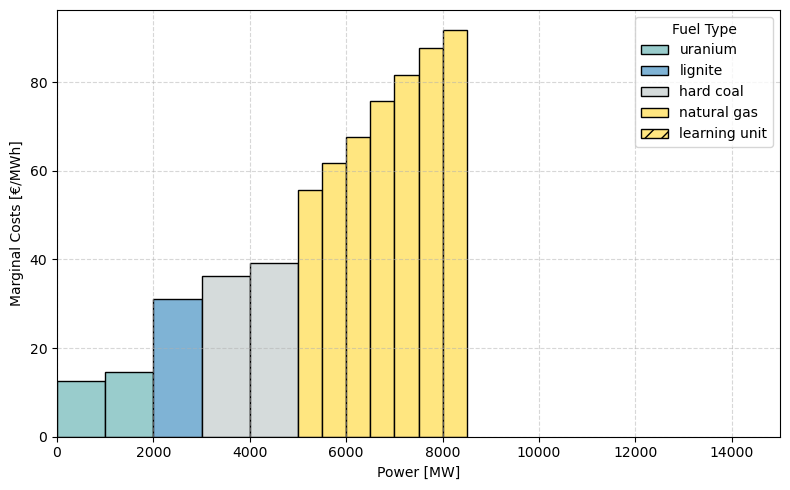

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Sortiere nach marginalen Kosten (mc)
gens_sorted = gens_df.sort_values("mc").reset_index(drop=True)

# Farben und Muster für die Balken
color_map = {
    "uranium": "#99cccc",
    "lignite": "#7fb3d5",
    "hard coal": "#d5dbdb",
    "natural gas": "#ffe680",
    "learning unit": "#ffe680",  # gleiche Farbe wie gas, aber mit Muster
}
hatch_map = {
    "learning unit": "//",
}

# Linke Kante für jeden Balken
left_edges = np.concatenate([[0], gens_sorted["g_max"].cumsum()[:-1]])

plt.figure(figsize=(8, 5))

bars = []
labels = []
for i, row in gens_sorted.iterrows():
    # Fuel-Type bestimmen
    if "bidding_EOM" in row and row["bidding_EOM"] == "pp_learning_single_bid":
        fuel = "learning unit"
    else:
        fuel = row["fuel_type"]
    color = color_map.get(fuel, "#cccccc")
    hatch = hatch_map.get(fuel, None)
    bar = plt.bar(
        left_edges[i],
        row["mc"],
        width=row["g_max"],
        align="edge",
        color=color,
        edgecolor="black",
        hatch=hatch,
        label=fuel if fuel not in labels else "",
    )
    bars.append(bar)
    labels.append(fuel)

# Legende manuell erstellen, damit jede Kategorie nur einmal erscheint
handles = []
legend_labels = []
for fuel, color in color_map.items():
    hatch = hatch_map.get(fuel, None)
    handle = plt.Rectangle(
        (0, 0), 1, 1, facecolor=color, edgecolor="black", hatch=hatch
    )
    handles.append(handle)
    legend_labels.append(fuel)

plt.legend(handles, legend_labels, title="Fuel Type", loc="upper right")
plt.xlabel("Power [MW]")
plt.ylabel("Marginal Costs [€/MWh]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 15000)
plt.tight_layout()
plt.show()

### Translate actions of RL model into k_values

In [20]:
# Merge on both 'unit_id' and 'time' columns
merged_df = sample_market_orders_df.merge(
    sample_dispatch_df[["unit", "time", "marginal_cost"]].reset_index(),
    left_on=["unit_id", "start_time"],
    right_on=["unit", "time"],
    how="left",
)
merged_df.head()

,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume,date,index,unit,time,marginal_cost
0,39.15625,1000.0,pp_1_1,None,2019-03-01 02:00:00.000000,EOM,node0,12.500000,example_02e_base,pp_1,1000.0,2019-03-01,15,pp_1,2019-03-01 01:00:00,12.500000
1,39.15625,1000.0,pp_2_1,None,2019-03-01 02:00:00.000000,EOM,node0,14.500000,example_02e_base,pp_2,1000.0,2019-03-01,18,pp_2,2019-03-01 01:00:00,14.500000
2,39.15625,1000.0,pp_3_1,None,2019-03-01 02:00:00.000000,EOM,node0,31.146341,example_02e_base,pp_3,1000.0,2019-03-01,21,pp_3,2019-03-01 01:00:00,31.146341
3,39.15625,1000.0,pp_4_1,None,2019-03-01 02:00:00.000000,EOM,node0,36.156250,example_02e_base,pp_4,1000.0,2019-03-01,25,pp_4,2019-03-01 01:00:00,36.156250
4,39.15625,920.7,pp_5_1,None,2019-03-01 02:00:00.000000,EOM,node0,39.156250,example_02e_base,pp_5,1000.0,2019-03-01,19,pp_5,2019-03-01 01:00:00,39.156250


storages do not have a mc value yet we need to get them from the storage_units_df depending on the direction of the valume we use the additional_costs_charge or discharge

In [21]:
# --- 1) storage_units vorbereiten (Index = unit_id) ---
storage_costs = storage_units.copy()

# Falls Name als Spalte vorliegt, nutze die als Index
if "name" in storage_costs.columns:
    storage_costs = storage_costs.set_index("name")

# Robuste Spaltennamen (je nach CSV/Schema)
charge_col = (
    "additional_cost_charge"
    if "additional_cost_charge" in storage_costs.columns
    else "additional_costs_charge"
)
discharge_col = (
    "additional_cost_discharge"
    if "additional_cost_discharge" in storage_costs.columns
    else "additional_costs_discharge"
)

# --- 2) Mapping für Storage-Kosten ---
charge_map = storage_costs[charge_col].to_dict()
discharge_map = storage_costs[discharge_col].to_dict()

# Nur Rows, die zu Storage-Units gehören
is_storage = merged_df["unit_id"].isin(storage_costs.index)

# --- 3) Marginal Cost für Storage aus Richtung (volume) setzen ---
# Konvention:
# volume < 0  -> charge  -> additional_cost_charge
# volume > 0  -> discharge -> additional_cost_discharge
# volume == 0 -> Mittelwert aus beiden
storage_mc = np.where(
    merged_df["volume"] < 0,
    merged_df["unit_id"].map(charge_map),
    np.where(
        merged_df["volume"] > 0,
        merged_df["unit_id"].map(discharge_map),
        (merged_df["unit_id"].map(charge_map) + merged_df["unit_id"].map(discharge_map))
        / 2,
    ),
)

# Nur für Storage-Zeilen schreiben (überschreibt dort ggf. NaN oder alte Werte)
merged_df.loc[is_storage, "marginal_cost"] = storage_mc[is_storage]

In [22]:
k_df = merged_df[["unit_id", "time", "price", "marginal_cost"]].copy()

k_df

,unit_id,time,price,marginal_cost
0,pp_1,2019-03-01 01:00:00,12.500000,12.500000
1,pp_2,2019-03-01 01:00:00,14.500000,14.500000
2,pp_3,2019-03-01 01:00:00,31.146341,31.146341
3,pp_4,2019-03-01 01:00:00,36.156250,36.156250
4,pp_5,2019-03-01 01:00:00,39.156250,39.156250
...,...,...,...,...
317,pp_9,2019-03-01 23:00:00,75.708333,75.708333
318,pp_10,2019-03-01 23:00:00,81.708333,81.708333
319,pp_11,2019-03-01 23:00:00,87.708333,87.708333
320,pp_12,2019-03-01 23:00:00,91.708333,91.708333


In [23]:
def obtain_k_values(k_df):
    # transformed actions into k_values, one per generator
    k_df["k"] = k_df["price"] / k_df["marginal_cost"]

    # replace inf with 0
    k_df["k"] = k_df["k"].replace(np.inf, 0)

    # delete rows where unit_id is none
    k_df = k_df[k_df["unit_id"].notna()]

    k_values_df = k_df.pivot(index="time", columns="unit_id", values="k")
    # k_values_df.reset_index(inplace=True)

    # sort columns to match the order of the columns in the gens_df
    k_values_df["date"] = k_values_df.index.date
    return k_values_df

In [24]:
k_values_df = obtain_k_values(k_df)
k_values_df.head()

unit_id,Storage 1,demand_EOM,pp_1,pp_10,pp_11,pp_12,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9,date
time,,,,,,,,,,,,,,,
2019-03-01 01:00:00,355.595807,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 02:00:00,355.782482,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 03:00:00,355.930083,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 04:00:00,356.062726,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01
2019-03-01 05:00:00,356.161526,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2019-03-01


In [25]:
# read availability df in same directory as powerplants and storages, if the file does not exist we initalize an empty df
try:
    availabilities = pd.read_csv(
        os.path.join(inputs_dir, scenario, "availability_df.csv"), index_col=0
    )
except FileNotFoundError:
    availabilities = pd.DataFrame()


availability_df = k_values_df.copy()
# drop column date
availability_df = availability_df.drop(columns=["date"])
# if columns in availabilities is also in k_values_df then we can use it directly otherwise we assume an availability of 1.0
# itterate over availability_df columns and check if present in availabilities columns
for col in availability_df.columns:
    if col in availabilities.columns:
        # use values in availabilities df where the index matches
        availability_df[col] = (
            availabilities[col].reindex(availability_df.index).fillna(1.0)
        )
    else:
        availability_df[col] = 1.0


availability_df.head()

unit_id,Storage 1,demand_EOM,pp_1,pp_10,pp_11,pp_12,pp_2,pp_3,pp_4,pp_5,pp_6,pp_7,pp_8,pp_9
time,,,,,,,,,,,,,,
2019-03-01 01:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-03-01 02:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-03-01 03:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-03-01 04:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2019-03-01 05:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Join demand and price bid

Since assume has the problem that the market always starts at 1 instead of zero we need to equal the modelling times here to avoid problems. 

In [26]:
# drop demand_df rows where start_time is not in sample_market_orders time column
sample_demand_df = sample_demand_df[
    sample_demand_df.index.isin(sample_market_orders_df.index)
]

demand_df = utils.join_demand_market_orders(sample_demand_df, sample_market_orders_df)
demand_df

,volume_1,price_1,date
datetime,,,
2019-03-01 01:00:00,4920.7,3000.0,2019-03-01
2019-03-01 02:00:00,4832.5,3000.0,2019-03-01
2019-03-01 03:00:00,4849.5,3000.0,2019-03-01
2019-03-01 04:00:00,5014.2,3000.0,2019-03-01
2019-03-01 05:00:00,5379.7,3000.0,2019-03-01
2019-03-01 06:00:00,6136.5,3000.0,2019-03-01
2019-03-01 07:00:00,6664.9,3000.0,2019-03-01
2019-03-01 08:00:00,6951.7,3000.0,2019-03-01
2019-03-01 09:00:00,7056.9,3000.0,2019-03-01


## Run MPEC

In [27]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

solver = SolverFactory("gurobi")


def find_optimal_dispatch_storage_leader_quadratic(
    gens_df,
    storage_df,
    demand_df,
    k_values_df,
    availabilities_df,
    opt_storage,
    k_max,
    big_w=10000,
    time_limit=360,
    demand_bids=1,
    big_M=10e6,
    print_results=False,
):
    """
    Monolithic quadratic MPEC with one strategic storage leader.

    Hybrid paper-aligned formulation:
    - Lower level follows the paper simplification for storage: only charging/discharging
      power enters the follower market-clearing/KKT block.
    - SoC dynamics and SoC bounds are NOT part of the lower-level KKT.
    - To keep the strategic storage physically feasible, SoC is retained only for the
      strategic storage opt_storage as upper-level feasibility constraints.

    This means:
    - non-strategic storages: represented in the follower only through p_charge/p_discharge
      and power bounds, consistent with the paper-style simplification.
    - strategic storage: additionally has SoC state constraints, but these are not dualized
      and do not appear in the KKT system.
    """
    if opt_storage not in k_values_df.columns:
        raise ValueError(
            f"opt_storage '{opt_storage}' not found in k_values_df columns"
        )
        


    model = pyo.ConcreteModel()

    # -------------------------------------------------------------------------
    # SETS
    # -------------------------------------------------------------------------
    model.time = pyo.Set(initialize=demand_df.index)
    model.gens = pyo.Set(initialize=gens_df.index)
    model.storages = pyo.Set(initialize=storage_df.index)
    model.demand_bids = pyo.Set(initialize=np.arange(1, demand_bids + 1))
    
    # tighter, index- und zeit-abhängige Big-Ms
    safety = 2  # 1.1..1.5 empfehlenswert
    eps = 1e-6

    # M für g - g_max Residuals (pro gen, pro time)
    big_M_gmax = {
        (i, t): max(eps, gens_df.at[i, "g_max"] * availabilities_df.at[t, i]) * safety
        for i in model.gens
        for t in model.time
    }
    
    # M für demand upper bounds (pro time, pro bid)
    big_M_demand = {
        (t, n): max(eps, demand_df.at[t, f"volume_{n}"]) * safety
        for t in model.time
        for n in model.demand_bids  
    }
    
    # M für storage power bounds (pro storage, pro time)
    big_M_storage_power = {
        (s, t): max(eps, abs(storage_df.at[s, "max_power_charge"])) * safety
        for s in model.storages
        for t in model.time
    }

    # -------------------------------------------------------------------------
    # PRIMAL LOWER-LEVEL VARIABLES
    # -------------------------------------------------------------------------
    model.g = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.d = pyo.Var(model.time, model.demand_bids, within=pyo.NonNegativeReals)
    model.c_up = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.c_down = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.u = pyo.Var(model.gens, model.time, within=pyo.Binary)

    # Storage power variables remain in the lower-level market clearing.
    model.p_charge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)
    model.p_discharge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)

    # Upper-level-only SoC state for the strategic storage.
    # This is NOT part of the lower-level KKT.
    model.soc = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # -------------------------------------------------------------------------
    # UPPER-LEVEL LEADER DECISION
    # -------------------------------------------------------------------------
    model.k = pyo.Var(model.time, bounds=(1, k_max), within=pyo.NonNegativeReals)
    model.storage_mode = pyo.Var(model.time, within=pyo.Binary)

    # -------------------------------------------------------------------------
    # DUAL VARIABLES FOR THE ECONOMIC LOWER LEVEL
    # -------------------------------------------------------------------------
    model.lambda_ = pyo.Var(model.time, within=pyo.Reals, bounds=(-500, 200))
    model.mu_max = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.mu_min = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.nu_max = pyo.Var(model.time, model.demand_bids, within=pyo.NonNegativeReals)

    model.pi_u = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.pi_d = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.sigma_u = pyo.Var(model.gens, model.time, bounds=(0, 1))
    model.sigma_d = pyo.Var(model.gens, model.time, bounds=(0, 1))
    model.psi_max = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)

    # Storage power-bound duals only.
    model.alpha_charge_max = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )
    model.alpha_discharge_max = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )

    # -------------------------------------------------------------------------
    # HAT DUALS FOR THE RELAXED / REFORMULATED KKT SYSTEM
    # -------------------------------------------------------------------------
    model.lambda_hat = pyo.Var(model.time, within=pyo.Reals, bounds=(0, 200))
    model.mu_max_hat = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.mu_min_hat = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.nu_max_hat = pyo.Var(
        model.time, model.demand_bids, within=pyo.NonNegativeReals
    )
    model.nu_min_hat = pyo.Var(
        model.time, model.demand_bids, within=pyo.NonNegativeReals
    )
    model.pi_u_hat = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.pi_d_hat = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)

    model.alpha_charge_max_hat = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )
    model.alpha_discharge_max_hat = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )

    # -------------------------------------------------------------------------
    # BINARIES FOR COMPLEMENTARITY LINEARIZATION
    # -------------------------------------------------------------------------
    model.mu_max_hat_binary = pyo.Var(model.gens, model.time, within=pyo.Binary)
    model.nu_max_hat_binary = pyo.Var(model.time, model.demand_bids, within=pyo.Binary)
    model.nu_min_hat_binary = pyo.Var(model.time, model.demand_bids, within=pyo.Binary)
    model.pi_u_hat_binary = pyo.Var(model.gens, model.time, within=pyo.Binary)
    model.pi_d_hat_binary = pyo.Var(model.gens, model.time, within=pyo.Binary)
    model.alpha_charge_max_hat_binary = pyo.Var(
        model.storages, model.time, within=pyo.Binary
    )
    model.alpha_discharge_max_hat_binary = pyo.Var(
        model.storages, model.time, within=pyo.Binary
    )

    def storage_bid_charge(model, s, t):
        # optionaler separater Kosteneintrag für Laden
        mc_charge = (
            storage_df.at[s, "additional_cost_charge"]
            if "additional_cost_charge" in storage_df.columns
            else storage_df.at[s, "mc"]
        )
        base_k = k_values_df.at[t, s]
        return model.k[t] * mc_charge if s == opt_storage else base_k * mc_charge

    def storage_bid_discharge(model, s, t):
        # optionaler separater Kosteneintrag für Entladen
        mc_discharge = (
            storage_df.at[s, "additional_cost_discharge"]
            if "additional_cost_discharge" in storage_df.columns
            else storage_df.at[s, "mc"]
        )
        base_k = k_values_df.at[t, s]
        return model.k[t] * mc_discharge if s == opt_storage else base_k * mc_discharge

    # -------------------------------------------------------------------------
    # OBJECTIVE
    # -------------------------------------------------------------------------
    def primary_objective_rule(model):
        return sum(
            model.lambda_hat[t]
            * (model.p_discharge[opt_storage, t] - model.p_charge[opt_storage, t])
            for t in model.time
        )

    def duality_gap_part_1_rule(model):
        # Lower-level Wohlfahrt (19, Wang) (1st and 2nd line)
        expr = sum(
            gens_df.at[gen, "mc"] * model.g[gen, t]
            + model.c_up[gen, t]
            + model.c_down[gen, t]
            for gen in model.gens
            for t in model.time
        )

        expr += sum(
            storage_bid_discharge(model, s, t) * model.p_discharge[s, t]
            - storage_bid_charge(model, s, t) * model.p_charge[s, t]
            for s in model.storages
            for t in model.time
        )

        expr -= sum(
            demand_df.at[t, f"price_{n}"] * model.d[t, n]
            for t in model.time
            for n in model.demand_bids
        )

        return expr

    def duality_gap_part_2_rule(model):
        # (7a) (3rd line)
        # objective value of the dual problem, using the current values of the dual variables
        expr = -sum(
            model.nu_max[t, n] * demand_df.at[t, f"volume_{n}"]
            for t in model.time
            for n in model.demand_bids
        )

        expr -= sum(
            model.pi_u[i, t] * gens_df.at[i, "r_up"]
            for i in model.gens
            for t in model.time
        )
        expr -= sum(
            model.pi_d[i, t] * gens_df.at[i, "r_down"]
            for i in model.gens
            for t in model.time
        )

        expr -= sum(model.pi_u[i, 0] * gens_df.at[i, "g_0"] for i in model.gens)
        expr += sum(model.pi_d[i, 0] * gens_df.at[i, "g_0"] for i in model.gens)

        expr -= sum(
            model.sigma_u[i, 0] * gens_df.at[i, "k_up"] * gens_df.at[i, "u_0"]
            for i in model.gens
        )
        expr += sum(
            model.sigma_d[i, 0] * gens_df.at[i, "k_down"] * gens_df.at[i, "u_0"]
            for i in model.gens
        )

        expr -= sum(model.psi_max[i, t] for i in model.gens for t in model.time)

        # adding this according to (19, Wang) to account for storage power bounds in the dual objective
        # somehow they do not seem to add this in the paper which really confuses me
        # or they do so (34, Wang) not entirely sure
        expr -= sum(
            model.alpha_charge_max[s, t] * abs(storage_df.at[s, "max_power_charge"])
            for s in model.storages
            for t in model.time
        )
        expr -= sum(
            model.alpha_discharge_max[s, t] * storage_df.at[s, "max_power_discharge"]
            for s in model.storages
            for t in model.time
        )

        return expr

    def final_objective_rule(model):
        return primary_objective_rule(model) - big_w * (
            duality_gap_part_1_rule(model) - duality_gap_part_2_rule(model)
        )

    model.objective = pyo.Objective(
        expr=final_objective_rule(model), sense=pyo.maximize
    )

    # -------------------------------------------------------------------------
    # PRIMAL LOWER-LEVEL CONSTRAINTS
    # -------------------------------------------------------------------------
    # Almost everything according to Nick just added some constraints where indicated
    def balance_rule(model, t):
        return (
            sum(model.d[t, n] for n in model.demand_bids)
            # add charge to demand
            + sum(model.p_charge[s, t] for s in model.storages)
            - sum(model.g[i, t] for i in model.gens)
            # add discharge to generation
            - sum(model.p_discharge[s, t] for s in model.storages)
            == 0
        )

    model.balance = pyo.Constraint(model.time, rule=balance_rule)

    # max generation constraint
    def g_max_rule(model, i, t):
        # (7e)
        return (
            model.g[i, t]
            <= gens_df.at[i, "g_max"] * availabilities_df.at[t, i] * model.u[i, t]
        )

    model.g_max = pyo.Constraint(model.gens, model.time, rule=g_max_rule)

    # max demand constraint
    def d_max_rule(model, t, n):
        # (7f)
        return model.d[t, n] <= demand_df.at[t, f"volume_{n}"]

    model.d_max = pyo.Constraint(model.time, model.demand_bids, rule=d_max_rule)

    # max ramp up constraint
    def ru_max_rule(model, i, t):
        # 	(7h)
        if t == 0:
            return model.g[i, t] - gens_df.at[i, "g_0"] <= gens_df.at[i, "r_up"]
        else:
            return model.g[i, t] - model.g[i, t - 1] <= gens_df.at[i, "r_up"]

    model.ru_max = pyo.Constraint(model.gens, model.time, rule=ru_max_rule)

    # max ramp down constraint
    def rd_max_rule(model, i, t):
        # (7i)
        if t == 0:
            return gens_df.at[i, "g_0"] - model.g[i, t] <= gens_df.at[i, "r_down"]
        else:
            return model.g[i, t - 1] - model.g[i, t] <= gens_df.at[i, "r_down"]

    model.rd_max = pyo.Constraint(model.gens, model.time, rule=rd_max_rule)

    # start up cost constraint
    def start_up_cost_rule(model, i, t):
        # (7m)
        if t == 0:
            return (
                model.c_up[i, t]
                >= (model.u[i, t] - gens_df.at[i, "u_0"]) * gens_df.at[i, "k_up"]
            )
        else:
            return (
                model.c_up[i, t]
                >= (model.u[i, t] - model.u[i, t - 1]) * gens_df.at[i, "k_up"]
            )

    model.start_up_cost = pyo.Constraint(
        model.gens, model.time, rule=start_up_cost_rule
    )

    # shut down cost constraint
    def shut_down_cost_rule(model, i, t):
        # (7n)
        if t == 0:
            return (
                model.c_down[i, t]
                >= (gens_df.at[i, "u_0"] - model.u[i, t]) * gens_df.at[i, "k_down"]
            )
        else:
            return (
                model.c_down[i, t]
                >= (model.u[i, t - 1] - model.u[i, t]) * gens_df.at[i, "k_down"]
            )

    model.shut_down_cost = pyo.Constraint(
        model.gens, model.time, rule=shut_down_cost_rule
    )

    # add storage constraints according to Wang
    # (24, Wang)
    def charge_exclusive_rule(model, t):
        return model.p_charge[opt_storage, t] <= abs(
            storage_df.at[opt_storage, "max_power_charge"]
        ) * (1 - model.storage_mode[t])

    model.charge_exclusive = pyo.Constraint(model.time, rule=charge_exclusive_rule)

    # (25, Wang)
    def discharge_exclusive_rule(model, t):
        return (
            model.p_discharge[opt_storage, t]
            <= storage_df.at[opt_storage, "max_power_discharge"] * model.storage_mode[t]
        )

    model.discharge_exclusive = pyo.Constraint(
        model.time, rule=discharge_exclusive_rule
    )

    # -------------------------------------------------------------------------
    # UPPER-LEVEL FEASIBILITY CONSTRAINTS FOR THE STRATEGIC STORAGE ONLY
    # -------------------------------------------------------------------------
    initial_soc_energy = (
        storage_df.at[opt_storage, "initial_soc"]
        * storage_df.at[opt_storage, "capacity"]
    )

    def soc_rule(model, t):
        # SoC dynamics only for the strategic storage.
        # This is NOT dualized and not part of the lower-level KKT.
        if t == 0:
            # (12, Wang)
            return (
                model.soc[t]
                - storage_df.at[opt_storage, "efficiency_charge"]
                * model.p_charge[opt_storage, t]
                + model.p_discharge[opt_storage, t]
                / storage_df.at[opt_storage, "efficiency_discharge"]
                == initial_soc_energy
            )
        # (13, Wang)
        return (
            model.soc[t]
            - model.soc[t - 1]
            - storage_df.at[opt_storage, "efficiency_charge"]
            * model.p_charge[opt_storage, t]
            + model.p_discharge[opt_storage, t]
            / storage_df.at[opt_storage, "efficiency_discharge"]
            == 0
        )

    model.soc_coupling = pyo.Constraint(model.time, rule=soc_rule)

    def soc_max_rule(model, t):
        # (14, Wang) without minimum SoC
        return model.soc[t] <= storage_df.at[opt_storage, "capacity"]

    model.soc_max = pyo.Constraint(model.time, rule=soc_max_rule)

    last_t = demand_df.index[-1]

    def terminal_soc_rule(model):
        return model.soc[last_t] == initial_soc_energy

    model.terminal_soc = pyo.Constraint(rule=terminal_soc_rule)

    # -------------------------------------------------------------------------
    # DUAL FEASIBILITY / STATIONARITY OF THE ECONOMIC LOWER LEVEL
    # -------------------------------------------------------------------------
    def gen_dual_rule(model, i, t):
        # (7aa) – Stationarity with respect to generation variable 𝑔𝑖,𝑡
        # Conditional parts based on `i` and `t`, now without opt_gen differentiation because we only have storage_opt now
        pi_u_next_term = 0 if t == model.time.at(-1) else model.pi_u[i, t + 1]
        pi_d_next_term = 0 if t == model.time.at(-1) else model.pi_d[i, t + 1]
        return (
            gens_df.at[i, "mc"] * k_values_df.at[t, i]
            - model.lambda_[t]
            + model.mu_max[i, t]
            - model.mu_min[i, t]
            + model.pi_u[i, t]
            - pi_u_next_term
            - model.pi_d[i, t]
            + pi_d_next_term
            == 0
        )

    model.gen_dual = pyo.Constraint(model.gens, model.time, rule=gen_dual_rule)

    def status_dual_rule(model, i, t):
        # (7ab) – Stationarity w.r.t. the binary unit commitment variable
        if t != model.time.at(-1):
            return (
                -model.mu_max[i, t]
                * gens_df.at[i, "g_max"]
                * availabilities_df.at[t, i]
                + (model.sigma_u[i, t] - model.sigma_u[i, t + 1])
                * gens_df.at[i, "k_up"]
                - (model.sigma_d[i, t] - model.sigma_d[i, t + 1])
                * gens_df.at[i, "k_down"]
                + model.psi_max[i, t]
                >= 0
            )
        else:
            return (
                -model.mu_max[i, t]
                * gens_df.at[i, "g_max"]
                * availabilities_df.at[t, i]
                + model.sigma_u[i, t] * gens_df.at[i, "k_up"]
                - model.sigma_d[i, t] * gens_df.at[i, "k_down"]
                + model.psi_max[i, t]
                >= 0
            )

    model.status_dual = pyo.Constraint(model.gens, model.time, rule=status_dual_rule)

    def demand_dual_rule(model, t, n):
        # (7ac) – Stationarity w.r.t. demand variable 𝑑𝑡
        return (
            -demand_df.at[t, f"price_{n}"] + model.lambda_[t] + model.nu_max[t, n] >= 0
        )

    model.demand_dual = pyo.Constraint(
        model.time, model.demand_bids, rule=demand_dual_rule
    )

    def storage_charge_dual_rule(model, s, t):
        # (37, Wang) dual feasibility
        return (
            -storage_bid_charge(model, s, t)
            + model.lambda_[t]
            + model.alpha_charge_max[s, t]
            >= 0
        )

    model.storage_charge_dual = pyo.Constraint(
        model.storages, model.time, rule=storage_charge_dual_rule
    )

    def storage_discharge_dual_rule(model, s, t):
        # (38, Wang) dual feasibility
        return (
            storage_bid_discharge(model, s, t)
            - model.lambda_[t]
            + model.alpha_discharge_max[s, t]
            >= 0
        )

    model.storage_discharge_dual = pyo.Constraint(
        model.storages, model.time, rule=storage_discharge_dual_rule
    )

    # -------------------------------------------------------------------------
    # RELAXED KKT STATIONARITY BLOCK (HAT SYSTEM)
    # -------------------------------------------------------------------------
    def kkt_gen_rule(model, i, t):
        # (7ae) – Stationarity (relaxed KKT) w.r.t. the generation variable 𝑔𝑖,𝑡
        # Conditional parts based on `i` and `t`, now without opt_gen differentiation because we only have storage_opt now
        pi_u_hat_next_term = 0 if t == model.time.at(-1) else model.pi_u_hat[i, t + 1]
        pi_d_hat_next_term = 0 if t == model.time.at(-1) else model.pi_d_hat[i, t + 1]
        return (
            gens_df.at[i, "mc"]
            - model.lambda_hat[t]
            + model.mu_max_hat[i, t]
            - model.mu_min_hat[i, t]
            + model.pi_u_hat[i, t]
            - pi_u_hat_next_term
            - model.pi_d_hat[i, t]
            + pi_d_hat_next_term
            == 0
        )

    model.kkt_gen = pyo.Constraint(model.gens, model.time, rule=kkt_gen_rule)

    def kkt_demand_rule(model, t, n):
        # (7af) – Stationarity (relaxed KKT) w.r.t. the demand variable 𝑑𝑡
        return (
            -demand_df.at[t, f"price_{n}"]
            + model.lambda_hat[t]
            + model.nu_max_hat[t, n]
            - model.nu_min_hat[t, n]
            == 0
        )

    model.kkt_demand = pyo.Constraint(
        model.time, model.demand_bids, rule=kkt_demand_rule
    )

    def kkt_storage_charge_rule(model, s, t):
        return (
            -storage_bid_charge(model, s, t)
            + model.lambda_hat[t]
            + model.alpha_charge_max_hat[s, t]
            >= 0
        )

    model.kkt_storage_charge = pyo.Constraint(
        model.storages, model.time, rule=kkt_storage_charge_rule
    )

    def kkt_storage_discharge_rule(model, s, t):
        return (
            storage_bid_discharge(model, s, t)
            - model.lambda_hat[t]
            + model.alpha_discharge_max_hat[s, t]
            >= 0
        )

    model.kkt_storage_discharge = pyo.Constraint(
        model.storages, model.time, rule=kkt_storage_discharge_rule
    )

    # -------------------------------------------------------------------------
    # COMPLEMENTARITY LINEARIZATION VIA BIG-M AND BINARIES
    # -------------------------------------------------------------------------
    # Complementary slackness conditions
    # for generation and demand upper bounds
    # (7t)–(7y), Relaxed or reformulated versions of (7ad)–(7ah), MILP-friendly using binaries + big-M
    def mu_max_hat_binary_rule_1(model, i, t):
        return (
            model.g[i, t]
            - gens_df.at[i, "g_max"] * availabilities_df.at[t, i] * model.u[i, t]
        ) <= max(gens_df["g_max"] * availabilities_df.at[t, i]) * (
            1 - model.mu_max_hat_binary[i, t]
        )

    def mu_max_hat_binary_rule_2(model, i, t):
        return (
            model.g[i, t]
            - gens_df.at[i, "g_max"] * availabilities_df.at[t, i] * model.u[i, t]
        ) >= -max(gens_df["g_max"] * availabilities_df.at[t, i]) * (
            1 - model.mu_max_hat_binary[i, t]
        )

    def mu_max_hat_binary_rule_3(model, i, t):
        return model.mu_max_hat[i, t] <= big_M * model.mu_max_hat_binary[i, t]

    model.mu_max_hat_binary_constr_1 = pyo.Constraint(
        model.gens, model.time, rule=mu_max_hat_binary_rule_1
    )
    model.mu_max_hat_binary_constr_2 = pyo.Constraint(
        model.gens, model.time, rule=mu_max_hat_binary_rule_2
    )
    model.mu_max_hat_binary_constr_3 = pyo.Constraint(
        model.gens, model.time, rule=mu_max_hat_binary_rule_3
    )

    def nu_max_hat_binary_rule_1(model, t, n):
        return model.d[t, n] - demand_df.at[t, f"volume_{n}"] <= big_M_demand[(t, n)] * (1 - model.nu_max_hat_binary[t, n])

    def nu_max_hat_binary_rule_2(model, t, n):
        return model.d[t, n] - demand_df.at[t, f"volume_{n}"] >= -big_M_demand[(t, n)] * (1 - model.nu_max_hat_binary[t, n])

    def nu_max_hat_binary_rule_3(model, t, n):
        return model.nu_max_hat[t, n] <= big_M * model.nu_max_hat_binary[t, n]

    model.nu_max_hat_binary_constr_1 = pyo.Constraint(
        model.time, model.demand_bids, rule=nu_max_hat_binary_rule_1
    )
    model.nu_max_hat_binary_constr_2 = pyo.Constraint(
        model.time, model.demand_bids, rule=nu_max_hat_binary_rule_2
    )
    model.nu_max_hat_binary_constr_3 = pyo.Constraint(
        model.time, model.demand_bids, rule=nu_max_hat_binary_rule_3
    )

    def nu_min_hat_binary_rule_1(model, t, n):
        return model.d[t, n] <= big_M * (1 - model.nu_min_hat_binary[t, n])

    def nu_min_hat_binary_rule_3(model, t, n):
        return model.nu_min_hat[t, n] <= big_M * model.nu_min_hat_binary[t, n]

    model.nu_min_hat_binary_constr_1 = pyo.Constraint(
        model.time, model.demand_bids, rule=nu_min_hat_binary_rule_1
    )

    model.nu_min_hat_binary_constr_3 = pyo.Constraint(
        model.time, model.demand_bids, rule=nu_min_hat_binary_rule_3
    )

    # Complementary slackness conditions
    # for ramp-up and ramp-down residuals
    # (??)–(??), Relaxed or reformulated versions of (7ai)–(7aj), MILP-friendly using binaries + big-M

    def pi_u_hat_binary_rule_1(model, i, t):
        if t == 0:
            return model.g[i, t] - gens_df.at[i, "g_0"] - gens_df.at[
                i, "r_up"
            ] <= big_M_gmax[(i, t)]  * (1 - model.pi_u_hat_binary[i, t])
        else:
            return model.g[i, t] - model.g[i, t - 1] - gens_df.at[
                i, "r_up"
            ] <= big_M_gmax[(i, t)]  * (1 - model.pi_u_hat_binary[i, t])

    def pi_u_hat_binary_rule_2(model, i, t):
        if t == 0:
            return model.g[i, t] - gens_df.at[i, "g_0"] - gens_df.at[
                i, "r_up"
            ] >= -big_M_gmax[(i, t)]  * (1 - model.pi_u_hat_binary[i, t])
        else:
            return model.g[i, t] - model.g[i, t - 1] - gens_df.at[
                i, "r_up"
            ] >= -big_M_gmax[(i, t)]  * (1 - model.pi_u_hat_binary[i, t])

    def pi_u_hat_binary_rule_3(model, i, t):
        return model.pi_u_hat[i, t] <= big_M * model.pi_u_hat_binary[i, t]

    model.pi_u_hat_binary_constr_1 = pyo.Constraint(
        model.gens, model.time, rule=pi_u_hat_binary_rule_1
    )
    model.pi_u_hat_binary_constr_2 = pyo.Constraint(
        model.gens, model.time, rule=pi_u_hat_binary_rule_2
    )
    model.pi_u_hat_binary_constr_3 = pyo.Constraint(
        model.gens, model.time, rule=pi_u_hat_binary_rule_3
    )

    def pi_d_hat_binary_rule_1(model, i, t):
        if t == 0:
            return gens_df.at[i, "g_0"] - model.g[i, t] - gens_df.at[
                i, "r_down"
            ] <= big_M_gmax[(i, t)]  * (1 - model.pi_d_hat_binary[i, t])
        else:
            return model.g[i, t - 1] - model.g[i, t] - gens_df.at[
                i, "r_down"
            ] <= big_M_gmax[(i, t)]  * (1 - model.pi_d_hat_binary[i, t])

    def pi_d_hat_binary_rule_2(model, i, t):
        if t == 0:
            return gens_df.at[i, "g_0"] - model.g[i, t] - gens_df.at[
                i, "r_down"
            ] >= -big_M_gmax[(i, t)]  * (1 - model.pi_d_hat_binary[i, t])
        else:
            return model.g[i, t - 1] - model.g[i, t] - gens_df.at[
                i, "r_down"
            ] >= -big_M_gmax[(i, t)]  * (1 - model.pi_d_hat_binary[i, t])

    def pi_d_hat_binary_rule_3(model, i, t):
        return model.pi_d_hat[i, t] <= big_M * model.pi_d_hat_binary[i, t]

    model.pi_d_hat_binary_constr_1 = pyo.Constraint(
        model.gens, model.time, rule=pi_d_hat_binary_rule_1
    )
    model.pi_d_hat_binary_constr_2 = pyo.Constraint(
        model.gens, model.time, rule=pi_d_hat_binary_rule_2
    )
    model.pi_d_hat_binary_constr_3 = pyo.Constraint(
        model.gens, model.time, rule=pi_d_hat_binary_rule_3
    )

    # Complementary slackness conditions for storage power bounds
    # reformulation of equation (50-51, Wang), MILP-friendly using binaries + big-M
    def alpha_charge_hat_binary_rule_1(model, s, t):
        return model.p_charge[s, t] - abs(
            storage_df.at[s, "max_power_charge"]
        ) <= big_M_storage_power[(s, t)] * (1 - model.alpha_charge_max_hat_binary[s, t])

    def alpha_charge_hat_binary_rule_2(model, s, t):
        return model.p_charge[s, t] - abs(
            storage_df.at[s, "max_power_charge"]
        ) >= -big_M_storage_power[(s, t)] * (1 - model.alpha_charge_max_hat_binary[s, t])

    def alpha_charge_hat_binary_rule_3(model, s, t):
        return (
            model.alpha_charge_max_hat[s, t]
            <= big_M_storage_power[(s, t)] * model.alpha_charge_max_hat_binary[s, t]
        )

    model.alpha_charge_hat_binary_constr_1 = pyo.Constraint(
        model.storages, model.time, rule=alpha_charge_hat_binary_rule_1
    )
    model.alpha_charge_hat_binary_constr_2 = pyo.Constraint(
        model.storages, model.time, rule=alpha_charge_hat_binary_rule_2
    )
    model.alpha_charge_hat_binary_constr_3 = pyo.Constraint(
        model.storages, model.time, rule=alpha_charge_hat_binary_rule_3
    )

    # reformulation of equation (48 - 49, Wang), MILP-friendly using binaries + big-M
    def alpha_discharge_hat_binary_rule_1(model, s, t):
        return model.p_discharge[s, t] - storage_df.at[
            s, "max_power_discharge"
        ] <= big_M_storage_power[(s, t)] * (1 - model.alpha_discharge_max_hat_binary[s, t])

    def alpha_discharge_hat_binary_rule_2(model, s, t):
        return model.p_discharge[s, t] - storage_df.at[
            s, "max_power_discharge"
        ] >= -big_M_storage_power[(s, t)] * (1 - model.alpha_discharge_max_hat_binary[s, t])

    def alpha_discharge_hat_binary_rule_3(model, s, t):
        return (
            model.alpha_discharge_max_hat[s, t]
            <= big_M_storage_power[(s, t)] * model.alpha_discharge_max_hat_binary[s, t]
        )

    model.alpha_discharge_hat_binary_constr_1 = pyo.Constraint(
        model.storages, model.time, rule=alpha_discharge_hat_binary_rule_1
    )
    model.alpha_discharge_hat_binary_constr_2 = pyo.Constraint(
        model.storages, model.time, rule=alpha_discharge_hat_binary_rule_2
    )
    model.alpha_discharge_hat_binary_constr_3 = pyo.Constraint(
        model.storages, model.time, rule=alpha_discharge_hat_binary_rule_3
    )

    # -------------------------------------------------------------------------
    # SOLVE
    # -------------------------------------------------------------------------
    instance = model.create_instance()
    solver = SolverFactory("gurobi")
    options = {
        "LogToConsole": print_results,
        "TimeLimit": time_limit,
        "MIPGap": 0.05,
        "MIPFocus": 1,
        "Heuristics": 0.5,
        "RINS": 10,
    }
    solver.options["NonConvex"] = 2
    results = solver.solve(instance, options=options, tee=print_results)

    if results.solver.termination_condition == pyo.TerminationCondition.maxTimeLimit:
        print("Solver did not converge to an optimal solution")

    # -------------------------------------------------------------------------
    # RESULT EXTRACTION
    # -------------------------------------------------------------------------
    generation_df = pd.DataFrame(
        index=demand_df.index, columns=[f"gen_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            generation_df.at[t, f"gen_{gen}"] = instance.g[gen, t].value

    charge_df = pd.DataFrame(
        index=demand_df.index, columns=[f"charge_{s}" for s in storage_df.index]
    )
    discharge_df = pd.DataFrame(
        index=demand_df.index, columns=[f"discharge_{s}" for s in storage_df.index]
    )
    for s in storage_df.index:
        for t in demand_df.index:
            charge_df.at[t, f"charge_{s}"] = instance.p_charge[s, t].value
            discharge_df.at[t, f"discharge_{s}"] = instance.p_discharge[s, t].value

    soc_df = pd.DataFrame(index=demand_df.index, columns=[f"soc_{opt_storage}"])
    for t in demand_df.index:
        soc_df.at[t, f"soc_{opt_storage}"] = instance.soc[t].value

    cleared_demand_df = pd.DataFrame(index=demand_df.index, columns=["demand"])
    for t in demand_df.index:
        cleared_demand_df.at[t, "demand"] = sum(
            instance.d[t, n].value for n in instance.demand_bids
        )

    mcp = pd.DataFrame(index=demand_df.index, columns=["mcp"])
    mcp_hat = pd.DataFrame(index=demand_df.index, columns=["mcp_hat"])
    for t in demand_df.index:
        mcp.at[t, "mcp"] = instance.lambda_[t].value
        mcp_hat.at[t, "mcp_hat"] = instance.lambda_hat[t].value

    main_df = pd.concat(
        [
            generation_df,
            charge_df,
            discharge_df,
            soc_df,
            cleared_demand_df,
            mcp,
            mcp_hat,
        ],
        axis=1,
    )

    start_up_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"start_up_{gen}" for gen in gens_df.index]
    )
    shut_down_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"shut_down_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            start_up_cost.at[t, f"start_up_{gen}"] = instance.c_up[gen, t].value
            shut_down_cost.at[t, f"shut_down_{gen}"] = instance.c_down[gen, t].value

    supp_df = pd.concat([start_up_cost, shut_down_cost], axis=1)

    k_values = pd.DataFrame(
        index=demand_df.index, columns=[opt_storage, "volume_storage"]
    )
    for t in demand_df.index:
        k_values.at[t, opt_storage] = instance.k[t].value
        k_values.at[t, "volume_storage"] = (
            - instance.p_charge[opt_storage, t].value
            + instance.p_discharge[opt_storage, t].value
        )

    return main_df, supp_df, k_values

In [28]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import numpy as np
import pandas as pd


def find_optimal_dispatch_storage_leader_quadratic_no_hat(
    gens_df,
    storage_df,
    demand_df,
    k_values_df,
    availabilities_df,
    opt_storage,
    k_max,
    big_w=10000,
    time_limit=360,
    demand_bids=1,
    print_results=False,
):
    """
    Simplified bilevel/MPEC draft without *_hat variables.

    Interpretation:
    - strategic storage chooses k[t]
    - lower level is represented through primal constraints + dual feasibility
    - upper-level objective uses lambda_ directly instead of lambda_hat
    - no additional pricing mechanism / no continuous fixed-UC pricing layer

    Important:
    This is a draft in the spirit of your current formulation, not a guaranteed
    exact reformulation of the paper.
    """

    if opt_storage not in k_values_df.columns:
        raise ValueError(
            f"opt_storage '{opt_storage}' not found in k_values_df columns"
        )

    model = pyo.ConcreteModel()

    # -------------------------------------------------------------------------
    # SETS
    # -------------------------------------------------------------------------
    model.time = pyo.Set(initialize=demand_df.index)
    model.gens = pyo.Set(initialize=gens_df.index)
    model.storages = pyo.Set(initialize=storage_df.index)
    model.demand_bids = pyo.Set(initialize=np.arange(1, demand_bids + 1))
    
        # tighter, index- und zeit-abhängige Big-Ms
    safety = 2  # 1.1..1.5 empfehlenswert
    eps = 1e-6

    # M für g - g_max Residuals (pro gen, pro time)
    big_M_gmax = {
        (i, t): max(eps, gens_df.at[i, "g_max"] * availabilities_df.at[t, i]) * safety
        for i in model.gens
        for t in model.time
    }
    
    # M für demand upper bounds (pro time, pro bid)
    big_M_demand = {
        (t, n): max(eps, demand_df.at[t, f"volume_{n}"]) * safety
        for t in model.time
        for n in model.demand_bids  
    }
    
    # M für storage power bounds (pro storage, pro time)
    big_M_storage_power = {
        (s, t): max(eps, abs(storage_df.at[s, "max_power_charge"])) * safety
        for s in model.storages
        for t in model.time
    }

    # -------------------------------------------------------------------------
    # PRIMAL VARIABLES
    # -------------------------------------------------------------------------
    model.g = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.d = pyo.Var(model.time, model.demand_bids, within=pyo.NonNegativeReals)
    model.c_up = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.c_down = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.u = pyo.Var(model.gens, model.time, within=pyo.Binary)

    model.p_charge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)
    model.p_discharge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)

    # upper-level physical feasibility only for strategic storage
    model.soc = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.storage_mode = pyo.Var(model.time, within=pyo.Binary)

    # upper-level strategic bid variable
    model.k = pyo.Var(model.time, bounds=(1, k_max), within=pyo.NonNegativeReals)

    # -------------------------------------------------------------------------
    # DUAL VARIABLES
    # -------------------------------------------------------------------------
    model.lambda_ = pyo.Var(model.time, within=pyo.Reals, bounds=(-500, 200))
    model.mu_max = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.mu_min = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.nu_max = pyo.Var(model.time, model.demand_bids, within=pyo.NonNegativeReals)

    model.pi_u = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.pi_d = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)
    model.sigma_u = pyo.Var(model.gens, model.time, bounds=(0, 1))
    model.sigma_d = pyo.Var(model.gens, model.time, bounds=(0, 1))
    model.psi_max = pyo.Var(model.gens, model.time, within=pyo.NonNegativeReals)

    model.alpha_charge_max = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )
    model.alpha_discharge_max = pyo.Var(
        model.storages, model.time, within=pyo.NonNegativeReals
    )

    def storage_bid_charge(model, s, t):
        mc_charge = (
            storage_df.at[s, "additional_cost_charge"]
            if "additional_cost_charge" in storage_df.columns
            else storage_df.at[s, "mc"]
        )
        base_k = k_values_df.at[t, s]
        return model.k[t] * mc_charge if s == opt_storage else base_k * mc_charge

    def storage_bid_discharge(model, s, t):
        mc_discharge = (
            storage_df.at[s, "additional_cost_discharge"]
            if "additional_cost_discharge" in storage_df.columns
            else storage_df.at[s, "mc"]
        )
        base_k = k_values_df.at[t, s]
        return model.k[t] * mc_discharge if s == opt_storage else base_k * mc_discharge

    # -------------------------------------------------------------------------
    # OBJECTIVE
    # -------------------------------------------------------------------------
    def primary_objective_rule(model):
        # no lambda_hat: use lambda_ directly
        return sum(
            model.lambda_[t]
            * (model.p_discharge[opt_storage, t] - model.p_charge[opt_storage, t])
            for t in model.time
        )

    def duality_gap_part_1_rule(model):
        expr = sum(
            gens_df.at[gen, "mc"] * model.g[gen, t]
            + model.c_up[gen, t]
            + model.c_down[gen, t]
            for gen in model.gens
            for t in model.time
        )

        expr += sum(
            storage_bid_discharge(model, s, t) * model.p_discharge[s, t]
            - storage_bid_charge(model, s, t) * model.p_charge[s, t]
            for s in model.storages
            for t in model.time
        )

        expr -= sum(
            demand_df.at[t, f"price_{n}"] * model.d[t, n]
            for t in model.time
            for n in model.demand_bids
        )

        return expr

    def duality_gap_part_2_rule(model):
        expr = -sum(
            model.nu_max[t, n] * demand_df.at[t, f"volume_{n}"]
            for t in model.time
            for n in model.demand_bids
        )

        expr -= sum(
            model.pi_u[i, t] * gens_df.at[i, "r_up"]
            for i in model.gens
            for t in model.time
        )
        expr -= sum(
            model.pi_d[i, t] * gens_df.at[i, "r_down"]
            for i in model.gens
            for t in model.time
        )

        expr -= sum(model.pi_u[i, 0] * gens_df.at[i, "g_0"] for i in model.gens)
        expr += sum(model.pi_d[i, 0] * gens_df.at[i, "g_0"] for i in model.gens)

        expr -= sum(
            model.sigma_u[i, 0] * gens_df.at[i, "k_up"] * gens_df.at[i, "u_0"]
            for i in model.gens
        )
        expr += sum(
            model.sigma_d[i, 0] * gens_df.at[i, "k_down"] * gens_df.at[i, "u_0"]
            for i in model.gens
        )

        expr -= sum(model.psi_max[i, t] for i in model.gens for t in model.time)
        
        # adding this according to (19, Wang) to account for storage power bounds in the dual objective
        # somehow they do not seem to add this in the paper which really confuses me
        # or they do so (34, Wang) not entirely sure
        expr -= sum(
            model.alpha_charge_max[s, t] * abs(storage_df.at[s, "max_power_charge"])
            for s in model.storages
            for t in model.time
        )
        expr -= sum(
            model.alpha_discharge_max[s, t] * storage_df.at[s, "max_power_discharge"]
            for s in model.storages
            for t in model.time
        )

        return expr

    def final_objective_rule(model):
        return primary_objective_rule(model) - big_w * (
            duality_gap_part_1_rule(model) - duality_gap_part_2_rule(model)
        )

    model.objective = pyo.Objective(
        expr=final_objective_rule(model), sense=pyo.maximize
    )

    # -------------------------------------------------------------------------
    # LOWER-LEVEL PRIMAL CONSTRAINTS
    # -------------------------------------------------------------------------
    def balance_rule(model, t):
        return (
            sum(model.d[t, n] for n in model.demand_bids)
            + sum(model.p_charge[s, t] for s in model.storages)
            - sum(model.g[i, t] for i in model.gens)
            - sum(model.p_discharge[s, t] for s in model.storages)
            == 0
        )

    model.balance = pyo.Constraint(model.time, rule=balance_rule)

    def g_max_rule(model, i, t):
        return (
            model.g[i, t]
            <= gens_df.at[i, "g_max"] * availabilities_df.at[t, i] * model.u[i, t]
        )

    model.g_max = pyo.Constraint(model.gens, model.time, rule=g_max_rule)

    def d_max_rule(model, t, n):
        return model.d[t, n] <= demand_df.at[t, f"volume_{n}"]

    model.d_max = pyo.Constraint(model.time, model.demand_bids, rule=d_max_rule)

    def ru_max_rule(model, i, t):
        if t == 0:
            return model.g[i, t] - gens_df.at[i, "g_0"] <= gens_df.at[i, "r_up"]
        return model.g[i, t] - model.g[i, t - 1] <= gens_df.at[i, "r_up"]

    model.ru_max = pyo.Constraint(model.gens, model.time, rule=ru_max_rule)

    def rd_max_rule(model, i, t):
        if t == 0:
            return gens_df.at[i, "g_0"] - model.g[i, t] <= gens_df.at[i, "r_down"]
        return model.g[i, t - 1] - model.g[i, t] <= gens_df.at[i, "r_down"]

    model.rd_max = pyo.Constraint(model.gens, model.time, rule=rd_max_rule)

    def start_up_cost_rule(model, i, t):
        if t == 0:
            return (
                model.c_up[i, t]
                >= (model.u[i, t] - gens_df.at[i, "u_0"]) * gens_df.at[i, "k_up"]
            )
        return (
            model.c_up[i, t]
            >= (model.u[i, t] - model.u[i, t - 1]) * gens_df.at[i, "k_up"]
        )

    model.start_up_cost = pyo.Constraint(
        model.gens, model.time, rule=start_up_cost_rule
    )

    def shut_down_cost_rule(model, i, t):
        if t == 0:
            return (
                model.c_down[i, t]
                >= (gens_df.at[i, "u_0"] - model.u[i, t]) * gens_df.at[i, "k_down"]
            )
        return (
            model.c_down[i, t]
            >= (model.u[i, t - 1] - model.u[i, t]) * gens_df.at[i, "k_down"]
        )

    model.shut_down_cost = pyo.Constraint(
        model.gens, model.time, rule=shut_down_cost_rule
    )

    def charge_max_rule(model, s, t):
        return model.p_charge[s, t] <= abs(storage_df.at[s, "max_power_charge"])

    model.charge_max = pyo.Constraint(model.storages, model.time, rule=charge_max_rule)

    def discharge_max_rule(model, s, t):
        return model.p_discharge[s, t] <= storage_df.at[s, "max_power_discharge"]

    model.discharge_max = pyo.Constraint(
        model.storages, model.time, rule=discharge_max_rule
    )

    # -------------------------------------------------------------------------
    # UPPER-LEVEL FEASIBILITY FOR STRATEGIC STORAGE
    # -------------------------------------------------------------------------
    initial_soc_energy = (
        storage_df.at[opt_storage, "initial_soc"] * storage_df.at[opt_storage, "capacity"]
    )
    last_t = demand_df.index[-1]

    def charge_exclusive_rule(model, t):
        return model.p_charge[opt_storage, t] <= abs(
            storage_df.at[opt_storage, "max_power_charge"]
        ) * (1 - model.storage_mode[t])

    model.charge_exclusive = pyo.Constraint(model.time, rule=charge_exclusive_rule)

    def discharge_exclusive_rule(model, t):
        return (
            model.p_discharge[opt_storage, t]
            <= storage_df.at[opt_storage, "max_power_discharge"] * model.storage_mode[t]
        )

    model.discharge_exclusive = pyo.Constraint(
        model.time, rule=discharge_exclusive_rule
    )

    def soc_rule(model, t):
        if t == 0:
            return (
                model.soc[t]
                - storage_df.at[opt_storage, "efficiency_charge"]
                * model.p_charge[opt_storage, t]
                + model.p_discharge[opt_storage, t]
                / storage_df.at[opt_storage, "efficiency_discharge"]
                == initial_soc_energy
            )
        return (
            model.soc[t]
            - model.soc[t - 1]
            - storage_df.at[opt_storage, "efficiency_charge"]
            * model.p_charge[opt_storage, t]
            + model.p_discharge[opt_storage, t]
            / storage_df.at[opt_storage, "efficiency_discharge"]
            == 0
        )

    model.soc_coupling = pyo.Constraint(model.time, rule=soc_rule)

    def soc_max_rule(model, t):
        return model.soc[t] <= storage_df.at[opt_storage, "capacity"]

    model.soc_max = pyo.Constraint(model.time, rule=soc_max_rule)

    def terminal_soc_rule(model):
        return model.soc[last_t] == initial_soc_energy

    model.terminal_soc = pyo.Constraint(rule=terminal_soc_rule)

    # -------------------------------------------------------------------------
    # DUAL FEASIBILITY / STATIONARITY
    # -------------------------------------------------------------------------
    def gen_dual_rule(model, i, t):
        pi_u_next_term = 0 if t == model.time.at(-1) else model.pi_u[i, t + 1]
        pi_d_next_term = 0 if t == model.time.at(-1) else model.pi_d[i, t + 1]
        return (
            gens_df.at[i, "mc"] * k_values_df.at[t, i]
            - model.lambda_[t]
            + model.mu_max[i, t]
            - model.mu_min[i, t]
            + model.pi_u[i, t]
            - pi_u_next_term
            - model.pi_d[i, t]
            + pi_d_next_term
            == 0
        )

    model.gen_dual = pyo.Constraint(model.gens, model.time, rule=gen_dual_rule)

    def status_dual_rule(model, i, t):
        if t != model.time.at(-1):
            return (
                -model.mu_max[i, t] * gens_df.at[i, "g_max"] * availabilities_df.at[t, i]
                + (model.sigma_u[i, t] - model.sigma_u[i, t + 1]) * gens_df.at[i, "k_up"]
                - (model.sigma_d[i, t] - model.sigma_d[i, t + 1]) * gens_df.at[i, "k_down"]
                + model.psi_max[i, t]
                >= 0
            )
        return (
            -model.mu_max[i, t] * gens_df.at[i, "g_max"] * availabilities_df.at[t, i]
            + model.sigma_u[i, t] * gens_df.at[i, "k_up"]
            - model.sigma_d[i, t] * gens_df.at[i, "k_down"]
            + model.psi_max[i, t]
            >= 0
        )

    model.status_dual = pyo.Constraint(model.gens, model.time, rule=status_dual_rule)

    def demand_dual_rule(model, t, n):
        return -demand_df.at[t, f"price_{n}"] + model.lambda_[t] + model.nu_max[t, n] >= 0

    model.demand_dual = pyo.Constraint(model.time, model.demand_bids, rule=demand_dual_rule)

    def storage_charge_dual_rule(model, s, t):
        return (
            -storage_bid_charge(model, s, t)
            + model.lambda_[t]
            + model.alpha_charge_max[s, t]
            >= 0
        )

    model.storage_charge_dual = pyo.Constraint(
        model.storages, model.time, rule=storage_charge_dual_rule
    )

    def storage_discharge_dual_rule(model, s, t):
        return (
            storage_bid_discharge(model, s, t)
            - model.lambda_[t]
            + model.alpha_discharge_max[s, t]
            >= 0
        )

    model.storage_discharge_dual = pyo.Constraint(
        model.storages, model.time, rule=storage_discharge_dual_rule
    )

    # -------------------------------------------------------------------------
    # SOLVE
    # -------------------------------------------------------------------------
    solver = SolverFactory("gurobi")
    options = {
        "LogToConsole": print_results,
        "TimeLimit": time_limit,
        "MIPGap": 0.03,
        "MIPFocus": 1,
    }
    solver.options["NonConvex"] = 2
    results = solver.solve(model, options=options, tee=print_results)
    
    if results.solver.termination_condition == pyo.TerminationCondition.maxTimeLimit:
        print("Solver did not converge to an optimal solution")

    # -------------------------------------------------------------------------
    # EXTRACT RESULTS
    # -------------------------------------------------------------------------
    generation_df = pd.DataFrame(
        index=demand_df.index, columns=[f"gen_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            generation_df.at[t, f"gen_{gen}"] = pyo.value(model.g[gen, t])

    charge_df = pd.DataFrame(
        index=demand_df.index, columns=[f"charge_{s}" for s in storage_df.index]
    )
    discharge_df = pd.DataFrame(
        index=demand_df.index, columns=[f"discharge_{s}" for s in storage_df.index]
    )
    for s in storage_df.index:
        for t in demand_df.index:
            charge_df.at[t, f"charge_{s}"] = pyo.value(model.p_charge[s, t])
            discharge_df.at[t, f"discharge_{s}"] = pyo.value(model.p_discharge[s, t])

    soc_df = pd.DataFrame(index=demand_df.index, columns=[f"soc_{opt_storage}"])
    for t in demand_df.index:
        soc_df.at[t, f"soc_{opt_storage}"] = pyo.value(model.soc[t])

    cleared_demand_df = pd.DataFrame(index=demand_df.index, columns=["demand"])
    for t in demand_df.index:
        cleared_demand_df.at[t, "demand"] = sum(
            pyo.value(model.d[t, n]) for n in model.demand_bids
        )

    mcp = pd.DataFrame(index=demand_df.index, columns=["mcp"])
    for t in demand_df.index:
        mcp.at[t, "mcp"] = pyo.value(model.lambda_[t])

    main_df = pd.concat(
        [generation_df, charge_df, discharge_df, soc_df, cleared_demand_df, mcp],
        axis=1,
    )

    start_up_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"start_up_{gen}" for gen in gens_df.index]
    )
    shut_down_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"shut_down_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            start_up_cost.at[t, f"start_up_{gen}"] = pyo.value(model.c_up[gen, t])
            shut_down_cost.at[t, f"shut_down_{gen}"] = pyo.value(model.c_down[gen, t])

    supp_df = pd.concat([start_up_cost, shut_down_cost], axis=1)

    k_values = pd.DataFrame(index=demand_df.index, columns=[opt_storage, "volume_storage"])
    for t in demand_df.index:
        k_values.at[t, opt_storage] = pyo.value(model.k[t])
        k_values.at[t, "volume_storage"] = (
            -pyo.value(model.p_charge[opt_storage, t])
            + pyo.value(model.p_discharge[opt_storage, t])
        )

    return main_df, supp_df, k_values

In [29]:
def solve_uc_problem_with_storage(
    gens_df,
    storage_df,
    demand_df,
    k_values_df,
    availabilities_df,
    storage_dispatch,
    demand_bids=1,
):
    """
    Draft UC problem with storage units.

    This keeps the original UC formulation as intact as possible and extends it by
    storage charge/discharge variables and a state-of-charge coupling over time.

    Expected storage_df columns
    ---------------------------
    - capacity
    - initial_soc
    - max_power_charge
    - max_power_discharge
    - efficiency_charge
    - efficiency_discharge
        - storage bid prices are provided via `storage_k_values_df`
            with the same index structure as `demand_df` and one column per storage

    Notes
    -----
        - Storage units bid time-varying prices via `storage_k_values_df.at[t, s]`.
        - The same price is used for charging and discharging.
    - `initial_soc` is interpreted as a fraction of capacity.
    - To keep the formulation simple and linear, there is no binary variable that
      forbids simultaneous charging and discharging.
    """
    model = pyo.ConcreteModel()

    # sets
    model.time = pyo.Set(initialize=demand_df.index)
    model.gens = pyo.Set(initialize=gens_df.index)
    model.storages = pyo.Set(initialize=storage_df.index)
    model.demand_bids = pyo.Set(initialize=np.arange(1, demand_bids + 1))

    # primary problem variables
    model.g = pyo.Var(
        model.gens, model.time, within=pyo.NonNegativeReals
    )  # Power output of producer i at period t (MW)
    model.d = pyo.Var(
        model.time, model.demand_bids, within=pyo.NonNegativeReals
    )  # satisfied demand at period t, from the multiple demand-bids n (MW)
    model.c_up = pyo.Var(
        model.gens, model.time, within=pyo.NonNegativeReals
    )  # Start-up cost of producer i at period t (€)
    model.c_down = pyo.Var(
        model.gens, model.time, within=pyo.NonNegativeReals
    )  # Shut-down cost of producer i at period t (€)
    model.u = pyo.Var(
        model.gens, model.time, within=pyo.Binary
    )  # Binary UC status of producer i at period t

    # storage variables
    model.p_charge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)
    model.p_discharge = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)
    model.soc = pyo.Var(model.storages, model.time, within=pyo.NonNegativeReals)

    # primary problem objective
    def objective_rule(model):
        expr = 0
        for gen in model.gens:
            for t in model.time:
                expr += (
                    k_values_df.at[t, gen] * gens_df.at[gen, "mc"] * model.g[gen, t]
                    + model.c_up[gen, t]
                    + model.c_down[gen, t]
                )

        for s in model.storages:
            for t in model.time:
                expr += k_values_df.at[t, s] * model.p_discharge[s, t]
                expr -= k_values_df.at[t, s] * model.p_charge[s, t]

        for t in model.time:
            for n in model.demand_bids:
                expr -= demand_df.at[t, f"price_{n}"] * model.d[t, n]

        return expr

    model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # energy balance constraint
    def balance_rule(model, t):
        return (
            sum(model.d[t, n] for n in model.demand_bids)
            + sum(model.p_charge[s, t] for s in model.storages)
            - sum(model.g[i, t] for i in model.gens)
            - sum(model.p_discharge[s, t] for s in model.storages)
            == 0
        )

    model.balance = pyo.Constraint(model.time, rule=balance_rule)

    # max generation constraint
    def g_max_rule(model, i, t):
        return (
            model.g[i, t]
            <= gens_df.at[i, "g_max"] * availabilities_df.at[t, i] * model.u[i, t]
        )

    model.g_max = pyo.Constraint(model.gens, model.time, rule=g_max_rule)

    # max demand constraint
    def d_max_rule(model, t, n):
        return model.d[t, n] <= demand_df.at[t, f"volume_{n}"]

    model.d_max = pyo.Constraint(model.time, model.demand_bids, rule=d_max_rule)

    last_t = demand_df.index[-1]

    # storage state of charge coupling
    def soc_rule(model, s, t):
        if t == 0:
            previous_soc = (
                storage_df.at[s, "initial_soc"] * storage_df.at[s, "capacity"]
            )
        else:
            previous_soc = model.soc[s, t - 1]

        return model.soc[s, t] == (
            previous_soc
            + storage_df.at[s, "efficiency_charge"] * model.p_charge[s, t]
            - model.p_discharge[s, t] / storage_df.at[s, "efficiency_discharge"]
        )

    model.soc_coupling = pyo.Constraint(model.storages, model.time, rule=soc_rule)

    def terminal_soc_rule(model, s):
        return model.soc[s, last_t] == (
            storage_df.at[s, "initial_soc"] * storage_df.at[s, "capacity"]
        )

    model.terminal_soc = pyo.Constraint(model.storages, rule=terminal_soc_rule)

    def soc_max_rule(model, s, t):
        return model.soc[s, t] <= storage_df.at[s, "capacity"]

    model.soc_max = pyo.Constraint(model.storages, model.time, rule=soc_max_rule)

    # exclusive charging and discharging constraints and storage power limits
    def charge_exclusive_rule(model, s, t):
        return model.p_charge[s, t] <= abs(min(storage_dispatch[t], 0))

    def discharge_exclusive_rule(model, s, t):
        return model.p_discharge[s, t] <= max(storage_dispatch[t], 0)

    model.charge_exclusive = pyo.Constraint(
        model.storages, model.time, rule=charge_exclusive_rule
    )
    model.discharge_exclusive = pyo.Constraint(
        model.storages, model.time, rule=discharge_exclusive_rule
    )

    # ramp up constraint
    def ramp_up_rule(model, i, t):
        if t == 0:
            return model.g[i, t] - gens_df.at[i, "g_0"] <= gens_df.at[i, "r_up"]
        else:
            return model.g[i, t] - model.g[i, t - 1] <= gens_df.at[i, "r_up"]

    model.ramp_up = pyo.Constraint(model.gens, model.time, rule=ramp_up_rule)

    # ramp down constraint
    def ramp_down_rule(model, i, t):
        if t == 0:
            return gens_df.at[i, "g_0"] - model.g[i, t] <= gens_df.at[i, "r_down"]
        else:
            return model.g[i, t - 1] - model.g[i, t] <= gens_df.at[i, "r_down"]

    model.ramp_down = pyo.Constraint(model.gens, model.time, rule=ramp_down_rule)

    # start up cost constraint
    def start_up_rule(model, i, t):
        if t == 0:
            return (
                model.c_up[i, t]
                - (model.u[i, t] - gens_df.at[i, "u_0"]) * gens_df.at[i, "k_up"]
                >= 0
            )
        else:
            return (
                model.c_up[i, t]
                - (model.u[i, t] - model.u[i, t - 1]) * gens_df.at[i, "k_up"]
                >= 0
            )

    model.start_up = pyo.Constraint(model.gens, model.time, rule=start_up_rule)

    # shut down cost constraint
    def shut_down_rule(model, i, t):
        if t == 0:
            return (
                model.c_down[i, t]
                - (gens_df.at[i, "u_0"] - model.u[i, t]) * gens_df.at[i, "k_down"]
                >= 0
            )
        else:
            return (
                model.c_down[i, t]
                - (model.u[i, t - 1] - model.u[i, t]) * gens_df.at[i, "k_down"]
                >= 0
            )

    model.shut_down = pyo.Constraint(model.gens, model.time, rule=shut_down_rule)

    # ---------------------------------------------------------------------------
    # solve
    instance = model.create_instance()

    solver = SolverFactory("gurobi")
    solver.solve(instance, tee=False)

    # make new instance with fixed u
    instance_fixed_u = model.create_instance()
    instance_fixed_u.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    for gen in gens_df.index:
        for t in demand_df.index:
            instance_fixed_u.u[gen, t].fix(instance.u[gen, t].value)

    solver.solve(instance_fixed_u, tee=False)

    # ---------------------------------------------------------------------------
    # extract results

    prices = pd.DataFrame(columns=["mcp"], index=demand_df.index, data=0.0)
    for t in demand_df.index:
        prices.loc[t, "mcp"] = -instance_fixed_u.dual[instance_fixed_u.balance[t]]

    generation = pd.DataFrame(
        columns=[f"gen_{gen}" for gen in gens_df.index],
        index=demand_df.index,
        data=0.0,
    )
    demand = pd.DataFrame(columns=["demand"], index=demand_df.index, data=0.0)
    charge = pd.DataFrame(
        columns=[f"charge_{s}" for s in storage_df.index],
        index=demand_df.index,
        data=0.0,
    )
    discharge = pd.DataFrame(
        columns=[f"discharge_{s}" for s in storage_df.index],
        index=demand_df.index,
        data=0.0,
    )
    soc = pd.DataFrame(
        columns=[f"soc_{s}" for s in storage_df.index],
        index=demand_df.index,
        data=0.0,
    )

    for gen in gens_df.index:
        for t in demand_df.index:
            generation.loc[t, f"gen_{gen}"] = instance_fixed_u.g[gen, t].value

    for t in demand_df.index:
        demand.loc[t, "demand"] = sum(
            instance_fixed_u.d[t, n].value for n in instance_fixed_u.demand_bids
        )

    for s in storage_df.index:
        for t in demand_df.index:
            charge.loc[t, f"charge_{s}"] = instance_fixed_u.p_charge[s, t].value
            discharge.loc[t, f"discharge_{s}"] = instance_fixed_u.p_discharge[
                s, t
            ].value
            soc.loc[t, f"soc_{s}"] = instance_fixed_u.soc[s, t].value

    main_df = pd.concat([generation, charge, discharge, soc, demand, prices], axis=1)

    start_up_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"start_up_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            start_up_cost.at[t, f"start_up_{gen}"] = instance_fixed_u.c_up[gen, t].value

    shut_down_cost = pd.DataFrame(
        index=demand_df.index, columns=[f"shut_down_{gen}" for gen in gens_df.index]
    )
    for gen in gens_df.index:
        for t in demand_df.index:
            shut_down_cost.at[t, f"shut_down_{gen}"] = instance_fixed_u.c_down[
                gen, t
            ].value

    supp_df = pd.concat([start_up_cost, shut_down_cost], axis=1)

    return main_df, supp_df

In [30]:
def run_MPEC(
    opt_storage,
    gens_df,
    demand_df,
    storage_df,
    k_values_df,
    availability_df,
    k_max,
    big_w,
    demand_bids=1,
):
    """
    Run the MPEC optimization for the given unit and return the profits before and after the optimization.

    Args:
        opt_storage (int): The storage unit to optimize.
        index (pd.Index): The index of the time series data.
        gens_df (pd.DataFrame): The generator data.
        demand_df (pd.DataFrame): The demand data.
        k_values_df (pd.DataFrame): The k-values data.
        availability_df (pd.DataFrame): The availability data [0,1].
        k_max (float): The maximum k-value.
        big_w (float): The big W value.

    Returns:
        tuple: The profits before and after the optimization.
    """
    print("We now optimize the decison for unit index", opt_storage)

    demand_df = demand_df.copy(deep=True)
    # reset index to start at 0
    demand_df = demand_df.reset_index(drop=True)

    k_values_df = k_values_df.copy(deep=True)
    # rename columns to match index of gens_df
    # k_values_df.columns = gens_df.index
    k_values_df.reset_index(inplace=True)

    availability_df = availability_df.copy(deep=True)
    # availability_df.columns = gens_df.index
    availability_df.reset_index(inplace=True)

    gens_df = gens_df.copy(deep=True)
    # set column unit as index
    gens_df.set_index("unit", inplace=True)
    storage_df = storage_df.copy(deep=True)
    # set columne name as index
    storage_df.set_index("name", inplace=True)

    main_df, supp_df, k_values = find_optimal_dispatch_storage_leader_quadratic_no_hat(
        gens_df=gens_df,
        storage_df=storage_df,
        k_values_df=k_values_df,
        availabilities_df=availability_df,
        demand_df=demand_df,
        k_max=k_max,
        opt_storage=opt_storage,
        big_w=big_w,
        time_limit=3600,
        print_results=True,
        #big_M=10e6,
        demand_bids=demand_bids,
    )

    # calculate actual market clearing prices

    k_values_df_2 = k_values_df.copy()
    k_values_df_2[opt_storage] = k_values[opt_storage]

    storage_dispatch = k_values["volume_storage"]

    updated_main_df_2, updated_supp_df_2 = solve_uc_problem_with_storage(
        gens_df,
        storage_df,
        demand_df,
        k_values_df_2,
        availability_df,
        storage_dispatch,
        demand_bids=demand_bids,
    )

    return main_df, supp_df, k_values, updated_main_df_2, updated_supp_df_2

In [31]:
start = pd.to_datetime("2019-03-01 01:00")
end = pd.to_datetime("2019-03-01 23:00")
index = pd.date_range(start, end, freq="h")

opt_name = "Storage 1"
# get index of opt_name from gens_df
opt_unit = 0
k_max = 300
 


demand_df_short = demand_df.copy().loc[index]
demand_df_short.drop(columns=["date"], inplace=True)

k_values_df_short = k_values_df.copy().loc[index]
k_values_df_short.drop(columns=["date"], inplace=True)

storage_units_short = storage_units.reset_index()

main_df, supp_df, k_values, updated_main_df_2, updated_supp_df_2 = run_MPEC(
    opt_storage=opt_name,
    gens_df=gens_df,
    storage_df=storage_units_short,
    demand_df=demand_df_short,
    k_values_df=k_values_df_short,
    availability_df=availability_df,
    k_max=k_max,
    big_w=big_w,
    demand_bids=1,
)

print("")
# print("Optimisation results:")
# print(f"Estimated Profits: {profits_1[opt_name].sum():.2f}")
# print(f"True profits: {profits_2[opt_name].sum():.2f}")

We now optimize the decison for unit index Storage 1
Set parameter Username
Academic license - for non-commercial use only - expires 2026-07-30
Read LP format model from file C:\Users\tg3533\AppData\Local\Temp\tmpcuevbna1.pyomo.lp
Reading time = 0.02 seconds
x1: 2186 rows, 2714 columns, 5449 nonzeros
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0.03
Set parameter MIPFocus to value 1
Gurobi Optimizer version 9.5.0 build v9.5.0rc5 (win64)
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads
Optimize a model with 2186 rows, 2714 columns and 5449 nonzeros
Model fingerprint: 0x0e2025ab
Model has 92 quadratic objective terms
Variable types: 2415 continuous, 299 integer (299 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+03]
  Objective range  [1e+05, 7e+08]
  QObjective range [2e+00, 6e+04]
  Bounds range     [1e+00, 5e+02]
  RHS range        [1e+01, 7e+03]
Found heuristic solution: objective -3

In [ ]:
main_df

In [ ]:
updated_main_df_2

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

max_xticks = 24

# select relevant columns
cols = [
    c
    for c in updated_main_df_2.columns
    if c.startswith("gen_") or c.startswith("charge_") or c.startswith("discharge_")
]
if len(cols) == 0:
    raise ValueError("No gen_/charge_/discharge_ columns found in updated_main_df_2")

df = updated_main_df_2[cols].fillna(0).copy()
# make charge negative so it plots below 0
charge_cols = [c for c in df.columns if c.startswith("charge_")]
df[charge_cols] = -df[charge_cols].abs()
neg_cols = charge_cols

# ordering: gens, discharges, discharges
gen_cols = [c for c in df.columns if c.startswith("gen_")]
discharge_cols = [c for c in df.columns if c.startswith("discharge_")]
pos_cols = gen_cols + discharge_cols

x = np.arange(len(df))
fig, ax = plt.subplots(figsize=(14, 6))

# stack positives
bottom_pos = np.zeros(len(df))
cmap = plt.get_cmap("tab20")
for i, col in enumerate(pos_cols):
    ax.bar(x, df[col].values, bottom=bottom_pos, label=col, color=cmap(i))
    bottom_pos = bottom_pos + df[col].values

# stack negatives (downwards)
bottom_neg = np.zeros(len(df))
for j, col in enumerate(neg_cols):
    idx = len(pos_cols) + j
    ax.bar(x, df[col].values, bottom=bottom_neg, label=col, color=cmap(idx))
    bottom_neg = bottom_neg + df[col].values  # df[col] is negative

# plot demand as line of ax
if "demand" in updated_main_df_2.columns:
    ax.step(
        x,
        updated_main_df_2["demand"].values,
        where="mid",
        label="demand",
        color="k",
        linestyle="--",
    )

# plot mcp column on second y axis if it exists
if "mcp" in updated_main_df_2.columns:
    ax2 = ax.twinx()
    ax2.step(
        x,
        updated_main_df_2["mcp"].values,
        where="mid",
        label="market clearing price",
        color="r",
        linestyle="-",
    )

    # for each time step I want to now what the marginal costs of the marginal egnerator is
    # this is the generator that sets the price, so I want to plot its marginal cost as well
    # to do this I need to find the marginal generator at each time step, which is the generator that has generation > 0 and has the highest number in the name (since we ordered them by gen_1, gen_2, etc.)
    
    marginal_gens = []
    for t in range(len(df)):
        gen_cols_t = [col for col in gen_cols if df.at[t, col] > 0]
        if len(gen_cols_t) > 0:
            # take last "_" segment as index (handles names like "gen_1" and "gen_pp_1")
            marginal_gen = max(gen_cols_t, key=lambda c: int(c.rsplit("_", 1)[-1]))
            marginal_gens.append(marginal_gen)
        else:
            marginal_gens.append(None)
    marginal_costs = []
    for t, gen in enumerate(marginal_gens):
        if gen is None:
            marginal_costs.append(0)
            continue

        # robustes Mapping: versuche numeric suffix direkt, sonst suffix-1 (falls labels 1-basiert)
        suffix = gen.rsplit("_", 1)[-1]
        mc = None
        try:
            idx = int(suffix)
            if (idx - 1) in gens_df.index:
                mc = gens_df.at[idx - 1, "mc"]
        except Exception:
            # fallback: versuche String-Index
            if suffix in gens_df.index:
                mc = gens_df.at[suffix, "mc"]

        if mc is None:
            # letzter Rettungsanker: erstes mc (oder NaN, je nach Präferenz)
            mc = gens_df["mc"].iloc[0]

        marginal_costs.append(mc)
    ax2.step(
        x,
        marginal_costs,
        label="marginal cost of marginal generator",
        where="mid",
        color="g",
        linestyle="-",
    )
    ax2.set_ylabel("marginal clearing price")
    ax2.legend(loc="upper right")
    ax2.set_ylim(0, updated_main_df_2["mcp"].max() * 1.2)


ax.axhline(0, color="k", linewidth=0.6)
ax.set_xlabel("Time step (row index)")
ax.set_ylabel("MW")
ax.set_title(
    "Stacked dispatch per time row (gen/charge positive, discharge plotted negative)"
)
# x ticks: limit to reasonable number
if len(df) <= max_xticks:
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in df.index], rotation=45, ha="right")
else:
    step = max(1, len(df) // max_xticks)
    ax.set_xticks(x[::step])
    ax.set_xticklabels([str(t) for t in df.index[::step]], rotation=45, ha="right")

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
demand_df = demand_df.copy(deep=True)
# reset index to start at 0
demand_df = demand_df.reset_index(drop=True)

k_values_df = k_values_df.copy(deep=True)
# rename columns to match index of gens_df
# k_values_df.columns = gens_df.index
k_values_df.reset_index(inplace=True)

availability_df = availability_df.copy(deep=True)
# availability_df.columns = gens_df.index
availability_df.reset_index(inplace=True)


solve_uc_problem_with_storage(
    gens_df,
    storage_units,
    demand_df,
    k_values_df,
    k_values_opt,
    availability_df,
    demand_bids=1,
)

In [ ]:
gens_df